# Lynx: Warp Regression on 100 Years of Trapping Data

In the [previous notebook](WarpDifferentiable.ipynb) I introduced warp regression on a clean synthetic example: one sine wave, one hidden warp, known ground truth. Nice for understanding the mechanics, but not exactly a stress test. Let's fix that.

The Hudson Bay Company kept records of lynx pelts trapped annually from 1821 to 1934. It's a simple, real dataset with a genuinely irregular cycle: counts boom and crash roughly every 10 years, but "roughly" is the key word. The cycle isn't a metronome. Some cycles run a bit long, some a bit short, and there's a subtler ~4-year wobble riding on top of the main 10-year rhythm.

That combination, a known, interpretable shape with wandering timing, is exactly warp regression's home turf. Here's what's new compared to the synthetic notebook:

- **Two sine cycles**, not one: a slow ~10-year cycle and a faster ~4-year cycle, sharing a single warp path.
- **Nonlinear output functions** (small MLPs) instead of a plain linear map, since the two cycles don't combine additively in a simple way.
- **Real, noisy, unevenly-behaved data** instead of a synthetic construction.
- **Raw counts, no log transform**: the nonlinear output functions in step 3 can already bend to the skewed amplitude, so there's no need to `log1p` the target first.

### Quick recap of the method

Same model as before: a warp path `p(i)` slides a cycle in time before it's passed through an output function, $\hat y(i) = f(\mathrm{warp}(c, p)(i))$, trained on a dual loss that balances fit quality (`obj_err`) against how implausible the warp is (`obj_time`, the *terror* term):

```
loss = λ·obj_err − (1−λ)·obj_time
```

Once fitted, we get two uncertainty flavours by sampling future warp paths forward from the train-end anchor:

- **terror band**: spread from stochastic warp-path continuations (timing uncertainty).
- **combined band**: terror plus observation noise, drawn jointly (the statistically honest way to stack the two).

### Two time axes

- The **sines** live on calendar time $t \in [0, 1]$, normalized over 1821-1934.
- The **warp** lives on **sample index** $i = 0, \ldots, n-1$: one index per year, so a 1-index shift is roughly a 1-year shift.

**Split:** train on 1821-1910, test on 1911-1934. Everything through step 3 only ever sees the training years; step 4 forecasts the held-out years and checks them against the actual trapping counts.


In [1]:

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

from warp_regression import (
    per_index_rw_sigma,
    plot_before_after_warp,
    plot_dual_objective_scatter,
    plot_fit_with_residual,
    plot_forecast_bands,
    plot_warp_offset,
    prefit,
    prepare_lynx_log,
    split_lynx_holdout,
)


## Step 1: load the data and get a rough pair of sines in place

First, load the series and split at 1910. Counts are heavily right-skewed (a handful of boom years dominate a raw scale), but rather than reach for the usual `log1p` fix we model raw counts directly: the nonlinear output functions in step 3 can already bend to that skew, so a separate variance-stabilizing transform isn't needed.

Then, before any warping happens, fit two fixed-frequency sines $z_1(t)$ and $z_2(t)$ directly on calendar time. Their sum is the **unwarped baseline**: what you'd get from a naive "two cycles, fixed period" model. We deliberately align $z_2$'s peaks to the big lynx booms so the warp has a sensible starting point to work from.


In [2]:
data = prepare_lynx_log(transform="identity")
years, counts, t, y = data["years"], data["counts"], data["t"], data["y_log"]

split = split_lynx_holdout(data, train_end_year=1910)
train_idx, test_idx = split["train_idx"], split["test_idx"]
years_tr, years_te = split["years_train"], split["years_test"]
y_tr, y_te = y[train_idx], y[test_idx]
t_tr = t[train_idx]
n_train = split["n_train"]

print(f"Train: {years_tr[0]}-{years_tr[-1]} (n={n_train})")
print(f"Test:  {years_te[0]}-{years_te[-1]} (n={split['n_test']})")

prefit_res = prefit(y_tr, t_tr, n_sines=2, years=years_tr)
fit = prefit_res.sine_fit
s1, s2 = fit["sine1"], fit["sine2"]
print(f"Sine 1: omega={s1['omega']:.3f}, period~{s1['period_years']:.1f} yr, a={s1['amplitude']:.3f}")
print(f"Sine 2: omega={s2['omega']:.3f}, period~{s2['period_years']:.1f} yr, peak_align={s2['peak_alignment']:.3f}")
print(f"Big peak years (train): {list(fit['big_peak_years'])}")
print(f"R2(train)={fit['r2_log']:.3f}, RMSE(train)={fit['rmse_log']:.1f}")


Train: 1821-1910 (n=90)
Test:  1911-1934 (n=24)
Sine 1: omega=11.750, period~7.7 yr, a=1750.646
Sine 2: omega=2.958, period~30.4 yr, peak_align=0.491
Big peak years (train): [np.int32(1828), np.int32(1838), np.int32(1866), np.int32(1885), np.int32(1895), np.int32(1904)]
R2(train)=0.657, RMSE(train)=962.3


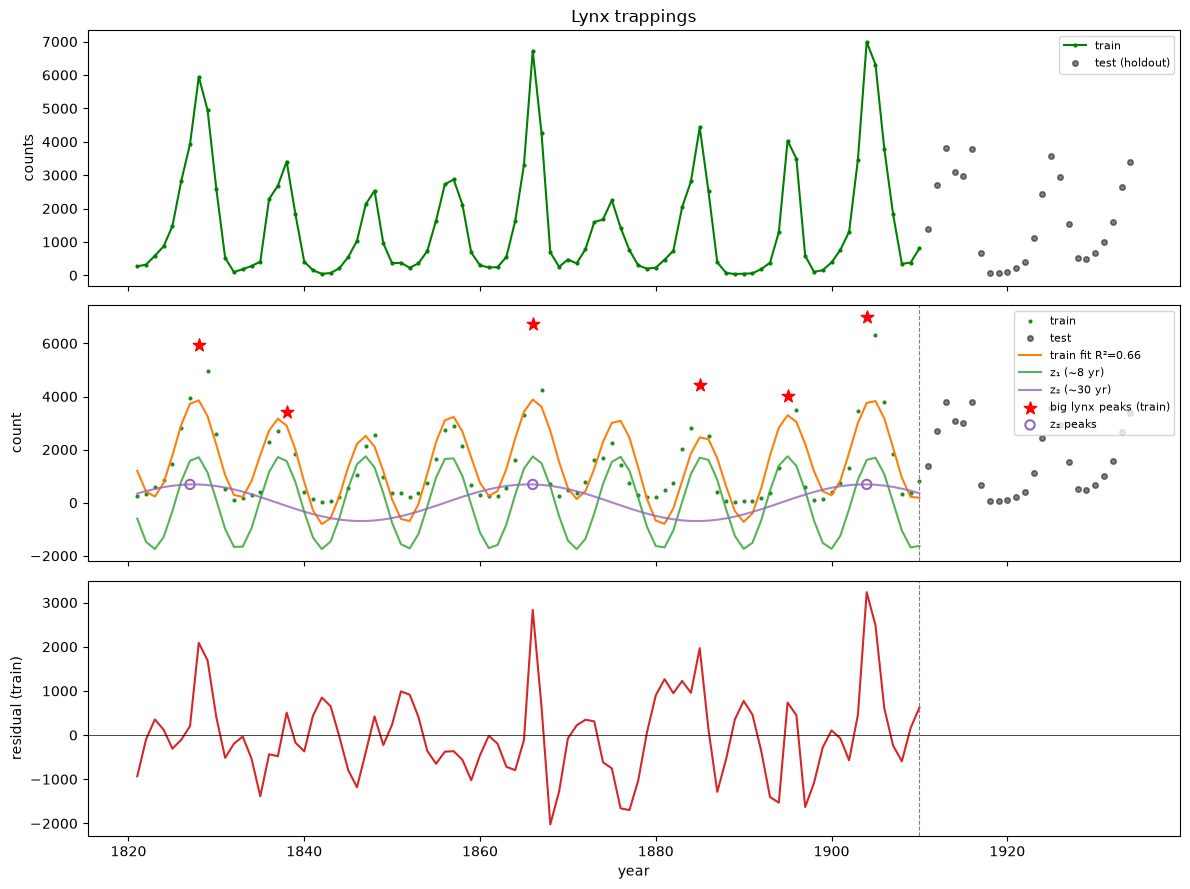

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].plot(years_tr, counts[train_idx], "g.-", ms=4, label="train")
axes[0].plot(years_te, counts[test_idx], "ko", ms=4, alpha=0.5, label="test (holdout)")
axes[0].set_ylabel("counts")
axes[0].set_title("Lynx trappings")
axes[0].legend(fontsize=8)

plot_fit_with_residual(
    axes[1:], years_tr, y_tr, fit["y_hat_log"],
    x_test=years_te, y_test=y_te,
    train_label="train", test_label="test",
    fit_label=f"train fit R²={fit['r2_log']:.2f}",
    extra_lines=[
        (years_tr, fit["component1_log"], {"color": "C2", "alpha": 0.8, "label": f"z₁ (~{s1['period_years']:.0f} yr)"}),
        (years_tr, fit["component2_log"], {"color": "C4", "alpha": 0.8, "label": f"z₂ (~{s2['period_years']:.0f} yr)"}),
    ],
    extra_scatter=[
        (years_tr[fit["big_peak_idx"]], y_tr[fit["big_peak_idx"]], {"s": 90, "c": "red", "marker": "*", "zorder": 5, "label": "big lynx peaks (train)"}),
        (years_tr[fit["z2_peak_idx"]], fit["component2_log"][fit["z2_peak_idx"]], {"s": 45, "facecolors": "none", "edgecolors": "C4", "lw": 1.5, "label": "z₂ peaks"}),
    ],
    ylabel="count", residual_ylabel="residual (train)", xlabel="year",
    forecast_start_x=split["train_end_year"],
)
plt.tight_layout()
plt.show()


## Step 2: one shared warp for both sines

Now the actual warp regression step. Both sines get warped by the *same* path, same idea as before, same dual loss:

```
loss = λ·obj_err − (1−λ)·terror_ll        (λ = 0.5)
```

`obj_err` is the Gaussian NLL of the lynx counts against the warped output function; `terror_ll` is the random-walk log-likelihood on the warp offsets `p − i`. Path scale $\sigma_t$ and observation noise $\sigma_y$ both come out of the fit.


In [4]:
from warp_regression import fit_dual_sine_shared_warp

fit_w = fit_dual_sine_shared_warp(
    y_tr, t_tr, years=years_tr, n_knots=14, epochs=1500, fit_lambda=0.5, sine_fit=fit
)
p = fit_w["warp"]["p"]
w = fit_w["warp"]
print(f"Before warp (train): R2={fit_w['r2_log_unwarped']:.3f}")
print(f"After warp (train):  R2={fit_w['r2_log']:.3f}  RMSE={fit_w['rmse_log']:.1f}")
print(f"Dual LL: obj_err={w['obj_err']:.1f}  obj_time={w['obj_time']:.1f}")
print(f"Learned sigma_t={w['sigma_t']:.3f} (path), sigma_y={w['sigma_y']:.1f} (fit), max|p-i|={w['max_abs_offset']:.2f}")


Before warp (train): R2=0.657
After warp (train):  R2=0.721  RMSE=868.0
Dual LL: obj_err=736.7  obj_time=0.2
Learned sigma_t=0.118 (path), sigma_y=868.3 (fit), max|p-i|=1.44


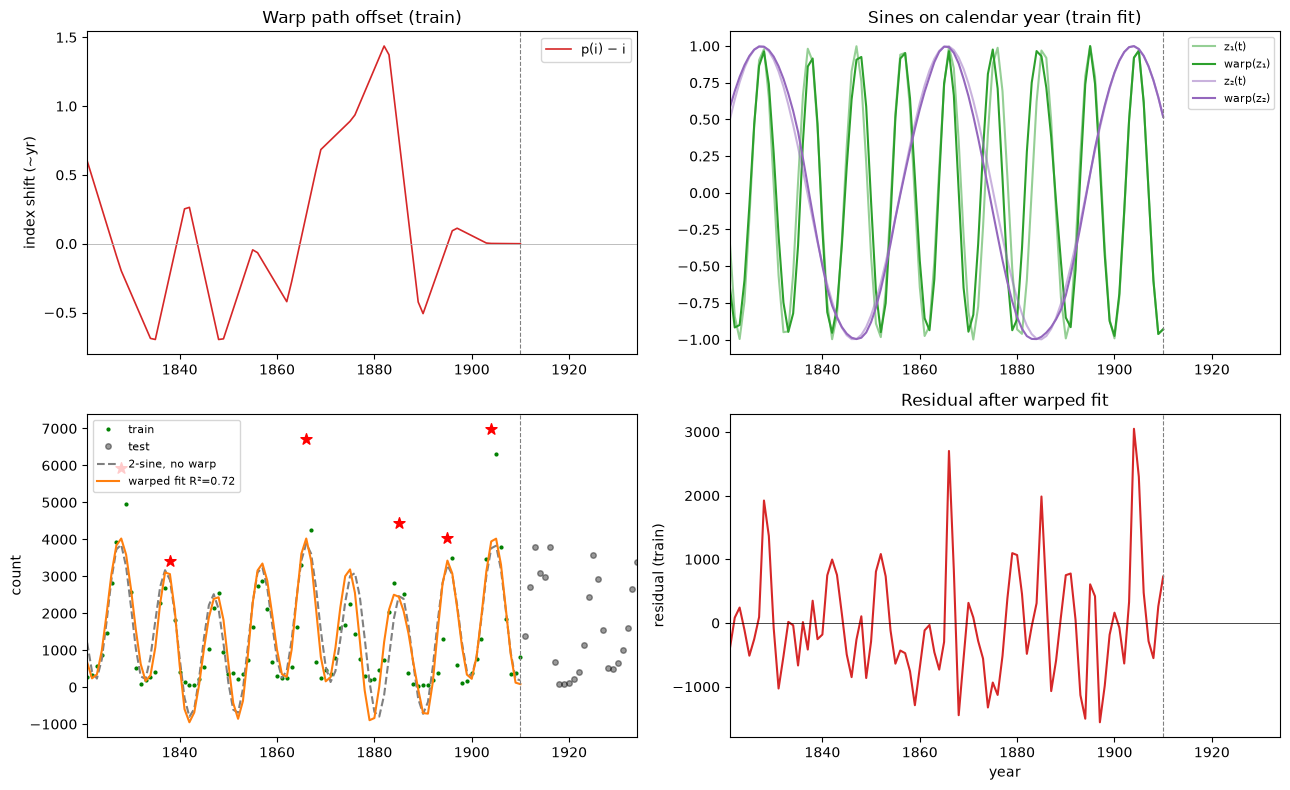

In [5]:
idx_tr = np.arange(n_train)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

plot_warp_offset(axes[0, 0], years_tr, p, label="p(i) − i", title="Warp path offset (train)")
axes[0, 0].set_ylabel("index shift (~yr)")

axes[0, 1].plot(years_tr, fit_w["z1"], "C2", alpha=0.5, label="z₁(t)")
axes[0, 1].plot(years_tr, fit_w["z1_warped"], "C2", lw=1.5, label="warp(z₁)")
axes[0, 1].plot(years_tr, fit_w["z2"], "C4", alpha=0.5, label="z₂(t)")
axes[0, 1].plot(years_tr, fit_w["z2_warped"], "C4", lw=1.5, label="warp(z₂)")
axes[0, 1].set_title("Sines on calendar year (train fit)")
axes[0, 1].legend(fontsize=8)

axes[1, 0].plot(years_tr, y_tr, "g.", ms=4, label="train")
axes[1, 0].plot(years_te, y_te, "ko", ms=4, alpha=0.4, label="test")
axes[1, 0].plot(years_tr, fit_w["y_hat_log_unwarped"], "--", color="gray", label="2-sine, no warp")
axes[1, 0].plot(years_tr, fit_w["y_hat_log"], "C1", lw=1.5, label=f"warped fit R²={fit_w['r2_log']:.2f}")
axes[1, 0].scatter(years_tr[fit_w["big_peak_idx"]], y_tr[fit_w["big_peak_idx"]], s=70, c="red", marker="*", zorder=5)
axes[1, 0].set_ylabel("count")
axes[1, 0].legend(fontsize=8)

axes[1, 1].plot(years_tr, y_tr - fit_w["y_hat_log"], "C3")
axes[1, 1].axhline(0, color="k", lw=0.5)
axes[1, 1].set_ylabel("residual (train)")
axes[1, 1].set_xlabel("year")
axes[1, 1].set_title("Residual after warped fit")

for ax in axes.ravel():
    ax.axvline(split["train_end_year"], color="gray", ls="--", lw=0.8)
    ax.set_xlim(years[0], years[-1])

plt.tight_layout()
plt.show()


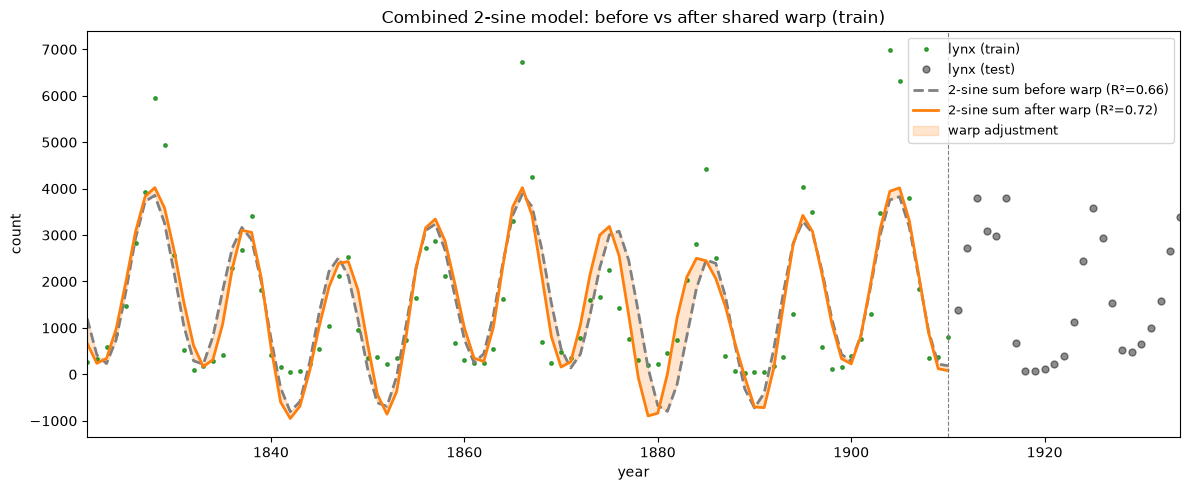

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
plot_before_after_warp(
    ax, years_tr, y_tr, fit_w["y_hat_log_unwarped"], fit_w["y_hat_log"],
    x_test=years_te, y_test=y_te,
    r2_before=fit_w["r2_log_unwarped"], r2_after=fit_w["r2_log"],
    before_label="2-sine sum before warp", after_label="2-sine sum after warp",
    train_label="lynx (train)", test_label="lynx (test)",
    forecast_start_x=split["train_end_year"],
    ylabel="count", xlabel="year",
    title="Combined 2-sine model: before vs after shared warp (train)",
)
ax.set_xlim(years[0], years[-1])
plt.tight_layout()
plt.show()


## Step 3: swap in nonlinear output functions

A straight sum of two sines is a strong assumption: real lynx dynamics aren't purely additive. So we replace the linear coefficients on each cycle with small MLPs ($f$ and $g$, hidden size 24, 2 layers: enough capacity to bend the shape a bit, not so much that the error term overfits). These MLPs also do double duty as the variance-stabilizing transform we'd otherwise reach for: since $f$ and $g$ are free-form, they can bend the amplitude to match the raw counts' skew directly, no `log1p` required.

$$\widehat{\text{lynx}} = f(\mathrm{warp}(z_1)) + g(\mathrm{warp}(z_2))$$

Still trained with $\lambda = 0.5$. The warp knots warm-start from the linear fit in step 2, so this is a genuine refinement, not training from scratch.


In [7]:
from warp_regression import fit_dual_sine_shared_warp_nonlinear

fit_nl = fit_dual_sine_shared_warp_nonlinear(
    y_tr, t_tr, years=years_tr, n_knots=14, epochs=2500, hidden=24, n_hidden_layers=2,
    fit_lambda=0.5, sine_fit=fit,
)
p_nl = fit_nl["warp"]["p"]
print(
    f"unwarped f+g (train): R2={fit_nl['r2_log_unwarped']:.3f}  |  "
    f"linear warp: R2={fit_nl['r2_log_linear_warp']:.3f}  |  "
    f"f(warp)+g(warp): R2={fit_nl['r2_log']:.3f}"
)
print(f"Dual LL: obj_err={fit_nl['warp']['obj_err']:.1f}  obj_time={fit_nl['warp']['obj_time']:.1f}")
print(f"sigma_y={fit_nl['warp']['sigma_y']:.1f}  max |p-i| ~ {fit_nl['warp']['max_abs_offset']:.2f} yr")


unwarped f+g (train): R2=0.657  |  linear warp: R2=0.721  |  f(warp)+g(warp): R2=0.982
Dual LL: obj_err=608.7  obj_time=0.5
sigma_y=210.3  max |p-i| ~ 1.54 yr


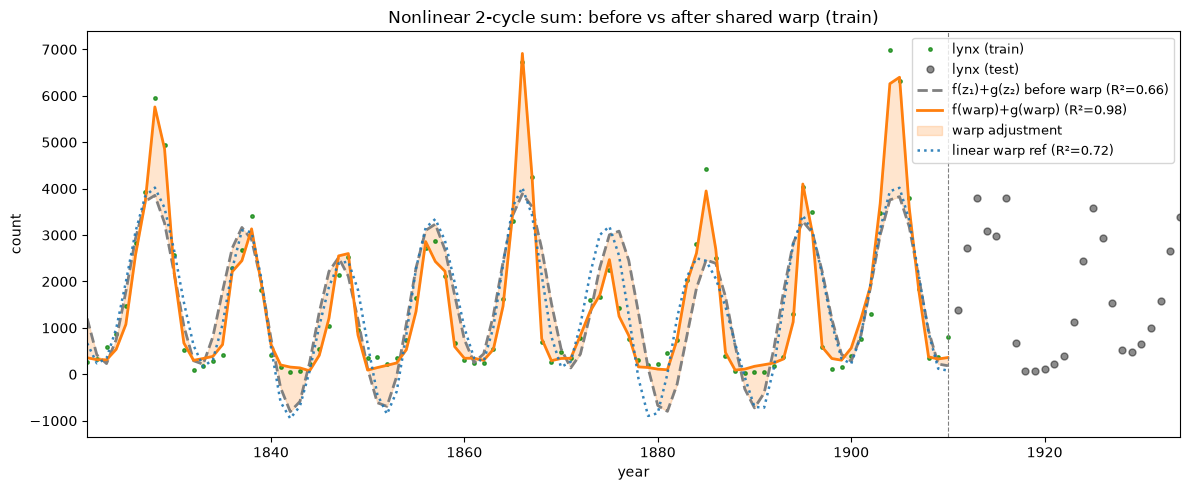

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
plot_before_after_warp(
    ax, years_tr, y_tr, fit_nl["y_hat_log_unwarped"], fit_nl["y_hat_log"],
    x_test=years_te, y_test=y_te,
    r2_before=fit_nl["r2_log_unwarped"], r2_after=fit_nl["r2_log"],
    before_label="f(z₁)+g(z₂) before warp", after_label="f(warp)+g(warp)",
    train_label="lynx (train)", test_label="lynx (test)",
    extra_lines=[(years_tr, fit_nl["y_hat_log_linear_warp"], {"color": "C0", "ls": ":", "lw": 1.8, "alpha": 0.9, "label": f"linear warp ref (R²={fit_nl['r2_log_linear_warp']:.2f})"})],
    forecast_start_x=split["train_end_year"],
    ylabel="count", xlabel="year",
    title="Nonlinear 2-cycle sum: before vs after shared warp (train)",
)
ax.set_xlim(years[0], years[-1])
plt.tight_layout()
plt.show()


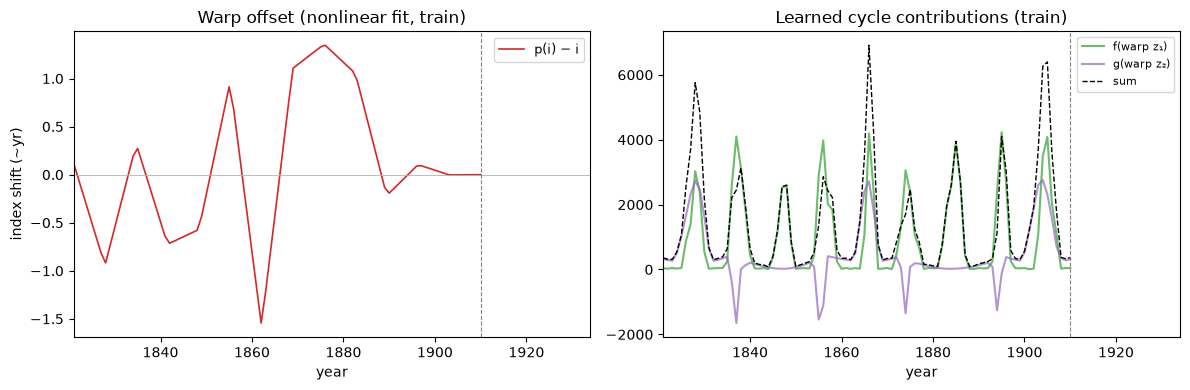

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_warp_offset(axes[0], years_tr, p_nl, label="p(i) − i", title="Warp offset (nonlinear fit, train)")
axes[0].set_ylabel("index shift (~yr)")
axes[1].plot(years_tr, fit_nl["component1_log"], "C2", alpha=0.7, label="f(warp z₁)")
axes[1].plot(years_tr, fit_nl["component2_log"], "C4", alpha=0.7, label="g(warp z₂)")
axes[1].plot(years_tr, fit_nl["y_hat_log"], "k--", lw=1, label="sum")
axes[1].set_title("Learned cycle contributions (train)")
axes[1].legend(fontsize=8)
for ax in axes:
    ax.axvline(split["train_end_year"], color="gray", ls="--", lw=0.8)
    ax.set_xlim(years[0], years[-1])
    ax.set_xlabel("year")
plt.tight_layout()
plt.show()


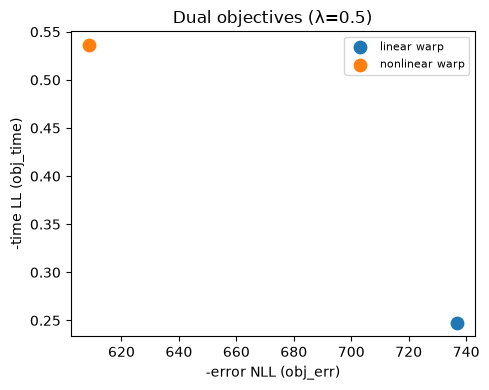

In [10]:
fig, ax = plt.subplots(figsize=(5, 4))
plot_dual_objective_scatter(
    ax,
    [
        {"x": fit_w["warp"]["obj_err"], "y": fit_w["warp"]["obj_time"], "label": "linear warp"},
        {"x": fit_nl["warp"]["obj_err"], "y": fit_nl["warp"]["obj_time"], "label": "nonlinear warp"},
    ],
    title="Dual objectives (λ=0.5)",
)
plt.tight_layout()
plt.show()


## Step 4: forecast the years we held out

Time to see if any of this actually predicts anything. We sample 500 stochastic warp paths beyond 1910, read out the count for each, and build **terror** and **combined** 95% bands exactly as in the synthetic notebook: combined bands come from a joint Monte Carlo draw (`paths_terror + N(0, σ_y²)`), not a naive sum of intervals.


In [11]:
from warp_regression import build_dual_sines_from_fit, forecast_lynx_holdout_paths

z1, z2 = build_dual_sines_from_fit(t, fit)
fit_nl["_y_log_train"] = y_tr
fit_nl["_y_log_test"] = y_te
fit_nl["warp"]["n_knots"] = 14

fc = forecast_lynx_holdout_paths(fit_nl, z1, z2, split, n_paths=500, seed=43)
bands = fc["bands"]
n_knots = fit_nl["warp"].get("n_knots", 14)

print(f"Train years {years_tr[0]}-{years_tr[-1]} (n={n_train})")
print(f"Test years  {years_te[0]}-{years_te[-1]} (n={split['n_test']})")
print(f"In-sample fit R2 (train, point path) = {fit_nl['r2_log']:.3f}")
print(f"Point forecast train/test corr = {fc['corr_log_train']:.3f} / {fc['corr_log_test']:.3f}")
print(f"Test RMSE (point) = {fc['rmse_log_test']:.1f}")
print(f"sigma_t={fc['sigma_t']:.3f}  sigma_y={fc['sigma_y']:.1f}  sigma_index={per_index_rw_sigma(fc['sigma_t'], n_train, n_knots):.3f}")
print(f"Test in combined 95% band: {fc['coverage_combined_95_test']*100:.0f}%")


Train years 1821-1910 (n=90)
Test years  1911-1934 (n=24)
In-sample fit R2 (train, point path) = 0.982
Point forecast train/test corr = 0.991 / 0.598
Test RMSE (point) = 1305.1
sigma_t=0.125  sigma_y=210.3  sigma_index=0.327
Test in combined 95% band: 92%


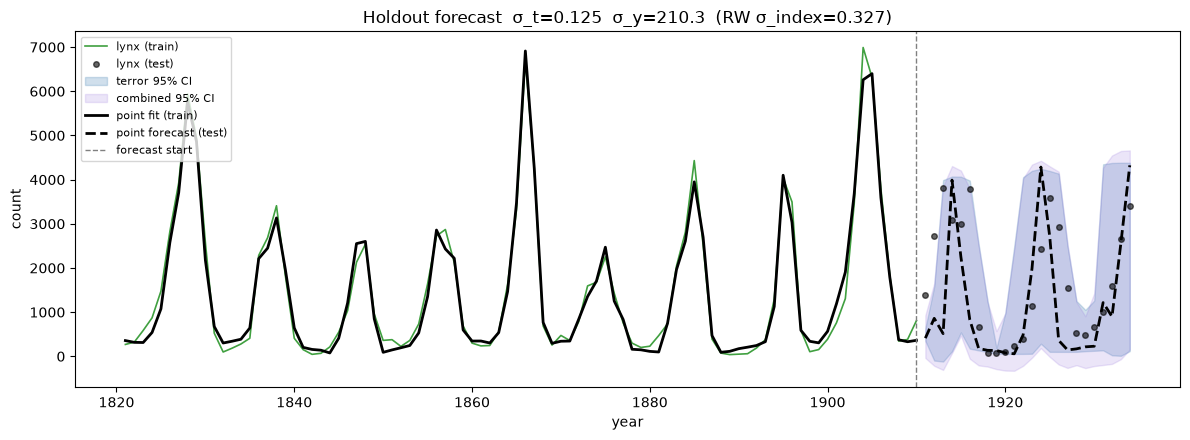

terror  band width at test start/end: 283 / 4262
combined band width at test start/end: 964 / 4505


In [12]:
train_end = split["train_end_year"]
y_point = fc["y_point"]
sigma_y = fc["sigma_y"]
yt = years[test_idx]
bands_test = {k: bands[k][test_idx] for k in ("t_q_lo", "t_q_hi", "c_q_lo", "c_q_hi")}

fig, ax = plt.subplots(figsize=(12, 4.5))
plot_forecast_bands(
    ax, years_tr, y_tr, yt, bands_test,
    x_test=yt, y_test=y_te,
    point_lines=[
        (years_tr, y_point[train_idx], {"color": "black", "lw": 2, "label": "point fit (train)"}),
        (yt, y_point[test_idx], {"color": "black", "lw": 2, "ls": "--", "label": "point forecast (test)"}),
    ],
    forecast_start_x=train_end,
    train_label="lynx (train)", test_label="lynx (test)",
    xlabel="year", ylabel="count",
    title=(
        f"Holdout forecast  σ_t={fc['sigma_t']:.3f}  σ_y={sigma_y:.1f}  "
        f"(RW σ_index={per_index_rw_sigma(fc['sigma_t'], n_train, n_knots):.3f})"
    ),
)
fig.tight_layout()
plt.show()

f0, f1 = test_idx[0], test_idx[-1]
print(f"terror  band width at test start/end: {(bands['t_q_hi'][f0]-bands['t_q_lo'][f0]):.0f} / {(bands['t_q_hi'][f1]-bands['t_q_lo'][f1]):.0f}")
print(f"combined band width at test start/end: {(bands['c_q_hi'][f0]-bands['c_q_lo'][f0]):.0f} / {(bands['c_q_hi'][f1]-bands['c_q_lo'][f1]):.0f}")


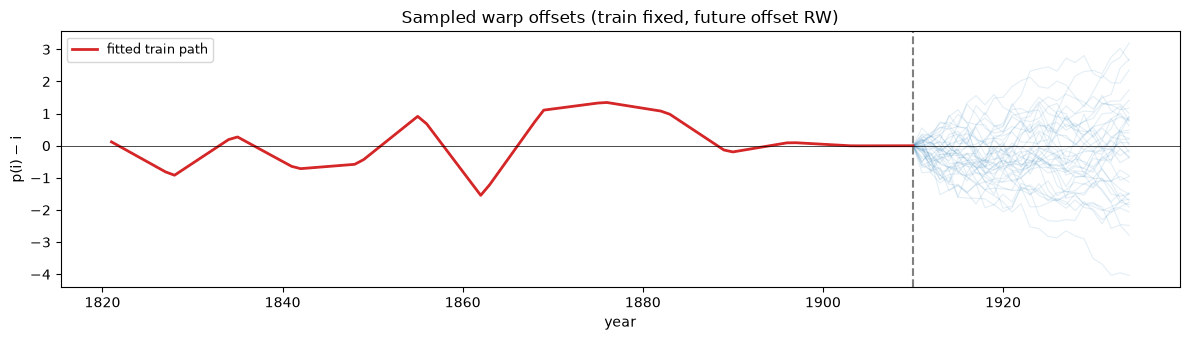

In [13]:
# What do the sampled future warp offsets actually look like against the fitted train path?
paths_p = fc["paths_p"]
idx = np.arange(len(years))
fig, ax = plt.subplots(figsize=(12, 3.5))
for k in range(min(40, len(paths_p))):
    ax.plot(years, paths_p[k] - idx, color="C0", alpha=0.12, lw=0.8)
ax.plot(years_tr, fit_nl["warp"]["p"] - idx[:n_train], "C3", lw=2, label="fitted train path")
ax.axvline(train_end, color="gray", ls="--")
ax.axhline(0, color="k", lw=0.5)
ax.set_ylabel("p(i) − i")
ax.set_xlabel("year")
ax.set_title("Sampled warp offsets (train fixed, future offset RW)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## Step 5: how long until the next boom?

The forecast bands above answer "how high will the count be". This next plot answers a different, arguably more interesting question: "when does the next lynx boom actually land?" We extend warp paths forward with the fitted $\sigma_t$ and measure the peak-to-peak spacing on the slow ~10-year component $z_1$. The dashed line marks the *nominal* period from the prefit: what you'd expect with a perfectly regular cycle.


Nominal cycle ≈ 7.7 yr  |  sample median = 8.0 yr  |  σ_t = 0.125


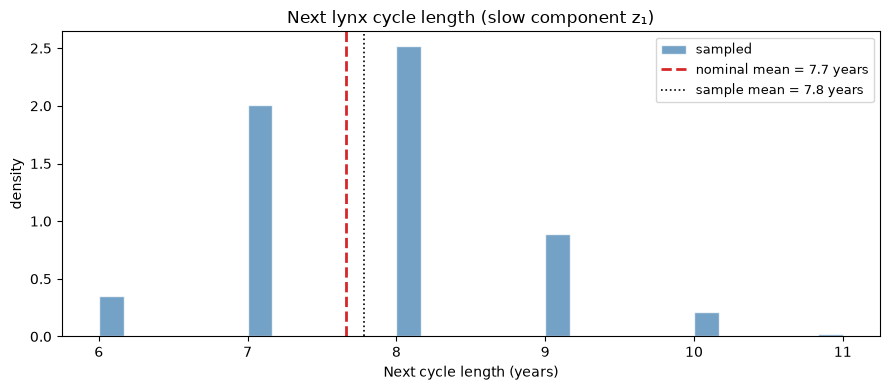

In [14]:
from warp_regression import analyze_cycle_lengths, plot_cycle_length_distribution

cyc = analyze_cycle_lengths(
    fit=fit_nl,
    n_calendar=n_train,
    unit="years",
    n_paths=500,
    seed=7,
)
fig, ax = plt.subplots(figsize=(9, 4))
plot_cycle_length_distribution(cyc, ax=ax, title="Next lynx cycle length (slow component z₁)")
print(
    f"Nominal cycle ≈ {cyc.mean_cycle_length:.1f} yr  |  "
    f"sample median = {np.median(cyc.lengths):.1f} yr  |  "
    f"σ_t = {cyc.sigma_t:.3f}"
)
fig.tight_layout()
plt.show()


## Step 6: how does this compare to a classical structural time series model?

Everything above is a custom method. It's fair to ask whether an established, off-the-shelf technique gets you the same thing with less effort. The closest classical match is Harvey's structural time series model: decompose the series into a level, a stochastic damped cycle, and irregular noise, each its own state-space recursion, and let a Kalman filter do the rest. `statsmodels` ships this directly as `UnobservedComponents`, so we can fit it on the exact same training years and forecast the exact same holdout.

One wrinkle worth flagging up front: the vanilla `UnobservedComponents` class supports a single cycle frequency. Lynx has two (a slow ~10-year boom-bust and a faster secondary wiggle), so this is not quite a fair fight, more a check on how far a single-cycle classical model gets on its own.

In [15]:
from statsmodels.tsa.statespace.structural import UnobservedComponents

counts_tr, counts_te = counts[train_idx], counts[test_idx]
y_hat_tr, y_hat_te = y_point[train_idx], y_point[test_idx]
in_combined = (counts_te >= bands_test["c_q_lo"]) & (counts_te <= bands_test["c_q_hi"])

# UnobservedComponents is a linear Gaussian model, so unlike the warp model's nonlinear
# output functions it still needs a log1p transform to behave on this right-skewed series.
# We fit it in log1p space and convert its forecast back to counts, so both models are
# compared on the same final scale.
y_log_tr = np.log1p(counts_tr)


def fit_harvey_ucm(stochastic_level: bool):
    m = UnobservedComponents(
        y_log_tr, level=True, stochastic_level=stochastic_level,
        cycle=True, stochastic_cycle=True, damped_cycle=True, irregular=True,
    )
    r = m.fit(disp=False, maxiter=500)
    freq = r.params[[i for i, n in enumerate(r.param_names) if "frequency" in n][0]]
    period = 2 * np.pi / freq
    fcst = r.get_forecast(steps=split["n_test"])
    mean_log = fcst.predicted_mean
    lo_log, hi_log = fcst.conf_int(alpha=0.05).T
    mean_c, lo_c, hi_c = np.expm1(mean_log), np.expm1(lo_log), np.expm1(hi_log)
    return {
        "res": r, "period": period, "mean_c": mean_c, "lo_c": lo_c, "hi_c": hi_c,
        "rmse_c": float(np.sqrt(np.mean((mean_c - counts_te) ** 2))),
        "cov_c": float(np.mean((counts_te >= lo_c) & (counts_te <= hi_c))),
        "width_c": float(np.mean(hi_c - lo_c)),
    }


ucm_fixed = fit_harvey_ucm(stochastic_level=False)
ucm_rw = fit_harvey_ucm(stochastic_level=True)

warp_rmse_c = float(np.sqrt(np.mean((y_hat_te - counts_te) ** 2)))
warp_cov_c = float(in_combined.mean())
warp_width_c = float(np.mean(bands_test["c_q_hi"] - bands_test["c_q_lo"]))

rows = [
    ("warp regression (2 cycles)", None, warp_rmse_c, warp_cov_c, warp_width_c),
    ("Harvey UCM, fixed level", ucm_fixed["period"], ucm_fixed["rmse_c"], ucm_fixed["cov_c"], ucm_fixed["width_c"]),
    ("Harvey UCM, random-walk level", ucm_rw["period"], ucm_rw["rmse_c"], ucm_rw["cov_c"], ucm_rw["width_c"]),
]
print(f"{'model':30s} {'period(yr)':>10s} {'RMSE(count)':>11s} {'cov95':>7s} {'width(count)':>12s}")
for name, period, rmse_c, cov, width in rows:
    period_s = f"{period:.1f}" if period is not None else "n/a"
    print(f"{name:30s} {period_s:>10s} {rmse_c:>11.0f} {cov*100:>6.0f}% {width:>12.0f}")

model                          period(yr) RMSE(count)   cov95 width(count)
warp regression (2 cycles)            n/a        1305     92%         3119
Harvey UCM, fixed level              10.6        1586     96%         6771
Harvey UCM, random-walk level         9.7        2058     92%        50420


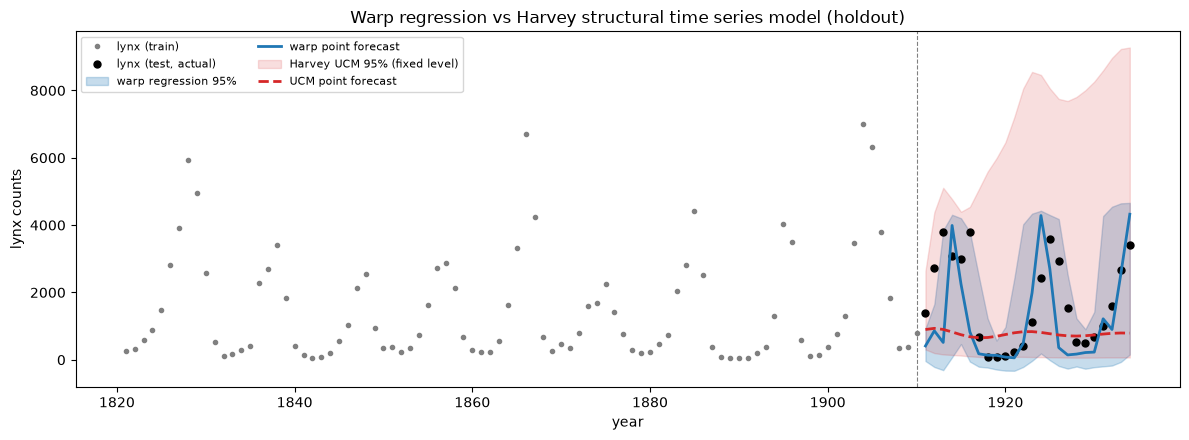

In [16]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(years_tr, counts_tr, "o", ms=3, color="0.5", label="lynx (train)")
ax.plot(yt, counts_te, "ko", ms=5, label="lynx (test, actual)")
ax.fill_between(yt, bands_test["c_q_lo"], bands_test["c_q_hi"], color="C0", alpha=0.25, label="warp regression 95%")
ax.plot(yt, y_hat_te, color="C0", lw=2, label="warp point forecast")
ax.fill_between(yt, ucm_fixed["lo_c"], ucm_fixed["hi_c"], color="C3", alpha=0.15, label="Harvey UCM 95% (fixed level)")
ax.plot(yt, ucm_fixed["mean_c"], color="C3", lw=2, ls="--", label="UCM point forecast")
ax.axvline(train_end, color="gray", ls="--", lw=0.8)
ax.set_ylabel("lynx counts")
ax.set_xlabel("year")
ax.set_title("Warp regression vs Harvey structural time series model (holdout)")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## Wrapping up

| Step | What happened |
|------|----------------|
| 1 | Loaded raw lynx trappings (no log transform), prefit two calendar-time sines |
| 2 | Fit one shared warp path across both sines (λ=0.5) |
| 3 | Swapped in nonlinear MLP output functions, warm-started from the linear warp |
| 4 | Forecast 1911–1934 in counts directly, with terror + combined 95% bands |
| 5 | Distribution over the next cycle's length, not just its height |
| 6 | Compared against Harvey's structural time series model |

Real data pushed on the method in ways the synthetic example couldn't: two competing cycles sharing one warp, a nonlinear output function, and actual forecast error against a holdout nobody peeked at during training. It held up reasonably well; see the coverage numbers above. Worth noting: the nonlinear output functions let us skip the `log1p` transform entirely, while the classical Harvey UCM baseline (a linear Gaussian model) still needed it internally to stay numerically stable on this right-skewed series. That's a small but real advantage of letting the output function absorb the shape rather than pre-transforming the target.

Next: **Bitcoin**, where the cycle is a single macro pattern riding on top of a strong trend, the data is daily instead of annual, and we'll also try correcting a persistent bias in the residuals with a simple moving-average layer on top of the warp forecast.
